In [1]:
import os
import sys
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import gc
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix, classification_report, precision_recall_curve, balanced_accuracy_score, matthews_corrcoef, average_precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterSampler
import matplotlib.pyplot as plt
import seaborn as sns

SEED=42

# 1. Načtení dat

In [2]:
lf_prohlidky = pl.scan_parquet(r"prohlidky_model.parquet")
lf_mereni = pl.scan_parquet(r"mereni_model_raw.parquet")
df = lf_prohlidky.join(lf_mereni, on='CisloProtokolu', how='inner').collect()#.sample(fraction=0.1, seed=SEED)

# 2. Definice proměnných

In [3]:
id_col = 'CisloProtokolu'
target_col = 'Vysledek_Pristi'

# Identifikace sloupců
all_cols = df.columns
feature_cols = [c for c in all_cols if c not in [id_col, target_col]]

# Automatická detekce kategorických a numerických sloupců
cat_features = [c for c in feature_cols if df[c].dtype in [pl.String, pl.Boolean, pl.Categorical]]
num_features = [c for c in feature_cols if df[c].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int8, pl.UInt32]]

# 3. Typová optimalizace (Polars) pro minimalizaci 

In [4]:
df = df.with_columns([
    pl.col(c).cast(pl.Float32) for c in num_features
]).with_columns([
    pl.col(c).cast(pl.String).fill_null("missing") for c in cat_features
]).with_columns(
    # Inverze zajistí, že 1 = Neúspěch.
    (1 - pl.col(target_col)).cast(pl.Int8).alias(target_col)
)

# 4. Konverze do Pandas 

In [5]:
# ID sloupec je vyřazen z trénovacích dat
df_pd = df.select(feature_cols + [target_col]).to_pandas()

# Odstranění Polars DataFrame z paměti
del df
_ = gc.collect()

# 5. Rozdělení dat (Train 80 %, Val 10 %, Test 10 %) se stratifikací

In [6]:
X = df_pd[feature_cols]
y = df_pd[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=SEED, stratify=y_temp)

# Odstranění dočasných proměnných
del df_pd, X, y, X_temp, y_temp
_ = gc.collect()

# 6. Inicializace objektů Pool

In [7]:
# Převedení dat do interního formátu CatBoost zefektivní využití paměti na GPU
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# 7. Konfigurace a trénování modelu 

In [8]:
DROP_RATIO = 0.1
PATIENCE = 2
MIN_FEATURES = 5

param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [6, 8],
    'l2_leaf_reg': [3, 5]
}

current_features = feature_cols.copy()
initial_feature_count = len(current_features)

best_overall_model = None
best_overall_f1 = 0
best_overall_thr = 0.5
best_overall_features = []

step = 1
patience_counter = 0

while len(current_features) >= MIN_FEATURES:
    print(f"\n=== Iterace {step} ===")
    print(f"Počet příznaků: {len(current_features)}")

    current_cat_features = [c for c in cat_features if c in current_features]

    train_pool = Pool(X_train[current_features], y_train, cat_features=current_cat_features)
    val_pool = Pool(X_val[current_features], y_val, cat_features=current_cat_features)

    param_list = list(ParameterSampler(param_grid, n_iter=4, random_state=SEED))
    
    best_step_f1 = 0
    best_step_thr = 0.5
    best_step_model = None

    for i, params in enumerate(param_list):
        model = CatBoostClassifier(
            iterations=2000,
            task_type='GPU',
            eval_metric='Logloss',
            loss_function='Logloss',
            random_seed=SEED,
            early_stopping_rounds=50,
            auto_class_weights='Balanced',
            verbose=100,
            **params
        )
        
        model.fit(train_pool, eval_set=val_pool)
        
        probs = model.predict_proba(val_pool)[:, 1]
        y_true = val_pool.get_label()
        
        thresholds = np.linspace(0.01, 0.95, 100)
        model_max_f1 = 0
        model_best_thr = 0.5
        
        for t in thresholds:
            score = f1_score(y_true, probs > t)
            if score > model_max_f1:
                model_max_f1 = score
                model_best_thr = t
        
        if model_max_f1 > best_step_f1:
            best_step_f1 = model_max_f1
            best_step_thr = model_best_thr
            best_step_model = model

    print(f"Nejlepší F1 v iteraci {step}: {best_step_f1:.4f} (práh: {best_step_thr:.4f})")

    if best_step_f1 > best_overall_f1:
        best_overall_f1 = best_step_f1
        best_overall_thr = best_step_thr
        best_overall_model = best_step_model
        best_overall_features = current_features.copy()
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Skóre se nezlepšilo. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Early stopping aktivován. Ukončuji iterativní ladění.")
        break

    fi = best_step_model.get_feature_importance(train_pool)
    df_fi = pd.DataFrame({'feature': current_features, 'importance': fi})
    df_fi = df_fi.sort_values(by='importance', ascending=False)
    
    drop_count = max(1, int(len(current_features) * DROP_RATIO))
    current_features = df_fi['feature'].head(len(current_features) - drop_count).tolist()
    print(f"Odstraněno {drop_count} nejméně důležitých příznaků.")
    
    step += 1

retained_ratio = (len(best_overall_features) / initial_feature_count) * 100

print("\n=== Iterativní proces dokončen ===")
print(f"Nejlepší celkové F1: {best_overall_f1:.4f} (práh: {best_overall_thr:.4f})")
print(f"Ponecháno příznaků: {len(best_overall_features)} ({retained_ratio:.2f} % z původních {initial_feature_count}).")


=== Iterace 1 ===
Počet příznaků: 222
0:	learn: 0.6848350	test: 0.6848444	best: 0.6848444 (0)	total: 658ms	remaining: 21m 54s
100:	learn: 0.5896246	test: 0.5907861	best: 0.5907861 (100)	total: 54.4s	remaining: 17m 2s
200:	learn: 0.5840720	test: 0.5866907	best: 0.5866907 (200)	total: 1m 49s	remaining: 16m 16s
300:	learn: 0.5805735	test: 0.5845734	best: 0.5845734 (300)	total: 2m 41s	remaining: 15m 11s
400:	learn: 0.5778299	test: 0.5832769	best: 0.5832769 (400)	total: 3m 36s	remaining: 14m 22s
500:	learn: 0.5755204	test: 0.5824430	best: 0.5824430 (500)	total: 4m 31s	remaining: 13m 30s
600:	learn: 0.5733144	test: 0.5817075	best: 0.5817075 (600)	total: 5m 25s	remaining: 12m 36s
700:	learn: 0.5712815	test: 0.5811680	best: 0.5811680 (700)	total: 6m 20s	remaining: 11m 45s
800:	learn: 0.5693661	test: 0.5807423	best: 0.5807423 (800)	total: 7m 16s	remaining: 10m 53s
900:	learn: 0.5675855	test: 0.5804651	best: 0.5804651 (900)	total: 8m 11s	remaining: 10m
1000:	learn: 0.5659080	test: 0.5801739	bes

# 8. Ulozeni vysledku

In [18]:
best_overall_model.save_model('model.bin')
print(best_overall_f1)
print(retained_ratio)
print(best_overall_thr)
print(best_overall_features)
print(cat_features)

0.1498035858178888
65.76576576576578
0.7506060606060605
['Vozidlo_TypMotoru', 'Stari_Vozidla_Let', 'Vysledek_Odometr', 'Nafta_MereniPrumer_Kourivost_Hodnota', 'Prohlidka_Stanice_Obec', 'Doba_Trvani_Emisi', 'Vozidlo_Znacka', 'Prohlidka_Stanice_ORP', 'Benzin_OtackyVolnobezne_COCOOR_Hodnota', 'Benzin_OtackyVolnobezne_O2_Hodnota', 'Prohlidka_Stanice_Cislo', 'MericiPristroj_VerzeSoftware', 'Nafta_Mereni0_Kourivost_Hodnota', 'Doba_Trvani_Prohlidky', 'Prohlidka_Cas_zahajeni', 'Prohlidka_Stanice_Kraj', 'Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 'Emise_OdpovednaOsoba', 'Prohlidka_OdpovednaOsoba', 'Benzin_OtackyVolnobezne_N_Hodnota', 'Benzin_OtackyZvysene_COCOOR_Hodnota', 'Benzin_OtackyVolnobezne_CO_Hodnota', 'Benzin_OtackyVolnobezne_CO2_Hodnota', 'Vysledek_Readiness', 'Benzin_OtackyVolnobezne_N_Min_Hodnota', 'Benzin_OtackyZvysene_O2_Hodnota', 'Obd_Readiness_Zazeh_CAT-FUNC_Otestovano', 'Benzin_OtackyZvysene_LAMBDA_Hodnota', 'Vozidlo_ObchodniOznaceni', 'Benzin_OtackyZvysene_CO_Hodnota', 'Ben

# 9. Vyhodnocení na testovací sadě

Použitý práh: 0.7506
F1 skore (Test): 0.1502
log_loss (Test): 0.5701

--- Klasifikační report na TESTOVACÍ sadě (1 = Neúspěch) ---
              precision    recall  f1-score   support

  Úspěch (0)       0.98      0.95      0.96    945089
Neúspěch (1)       0.11      0.24      0.15     25692

    accuracy                           0.93    970781
   macro avg       0.54      0.59      0.56    970781
weighted avg       0.96      0.93      0.94    970781



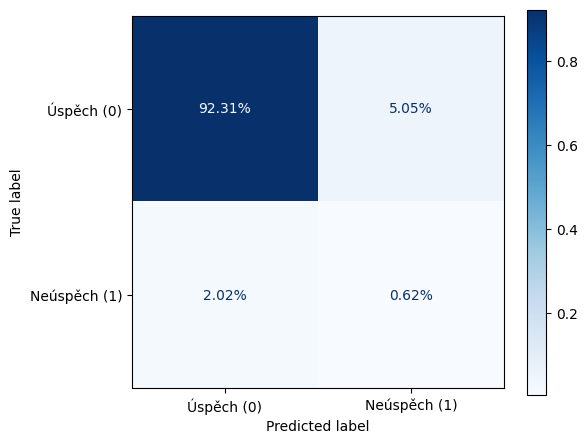

In [17]:
# Aplikace fixního prahu a vyhodnocení na TESTOVACÍ SADĚ
y_test_proba = model.predict_proba(test_pool)[:, 1]
y_test_labels = test_pool.get_label()
y_test_pred = (y_test_proba >= best_overall_thr).astype(int)

# Výpočet matic (absolutní i relativní)
cm_abs = confusion_matrix(y_test_labels, y_test_pred)
cm_rel = confusion_matrix(y_test_labels, y_test_pred, normalize='all')

# Výpis ukazatelů
print(f"Použitý práh: {best_overall_thr:.4f}")
print(f"F1 skore (Test): {f1_score(y_test_labels, y_test_pred):.4f}")
print(f"log_loss (Test): {log_loss(y_test_labels, y_test_proba):.4f}")
print("\n--- Klasifikační report na TESTOVACÍ sadě (1 = Neúspěch) ---")
print(classification_report(y_test_labels, y_test_pred, target_names=['Úspěch (0)', 'Neúspěch (1)']))

# Vizualizace relativní matice záměn
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rel, 
    display_labels=['Úspěch (0)', 'Neúspěch (1)']
)
_ = disp.plot(cmap='Blues', ax=ax, values_format='.2%')

/tmp/ipykernel_10036/1593147820.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


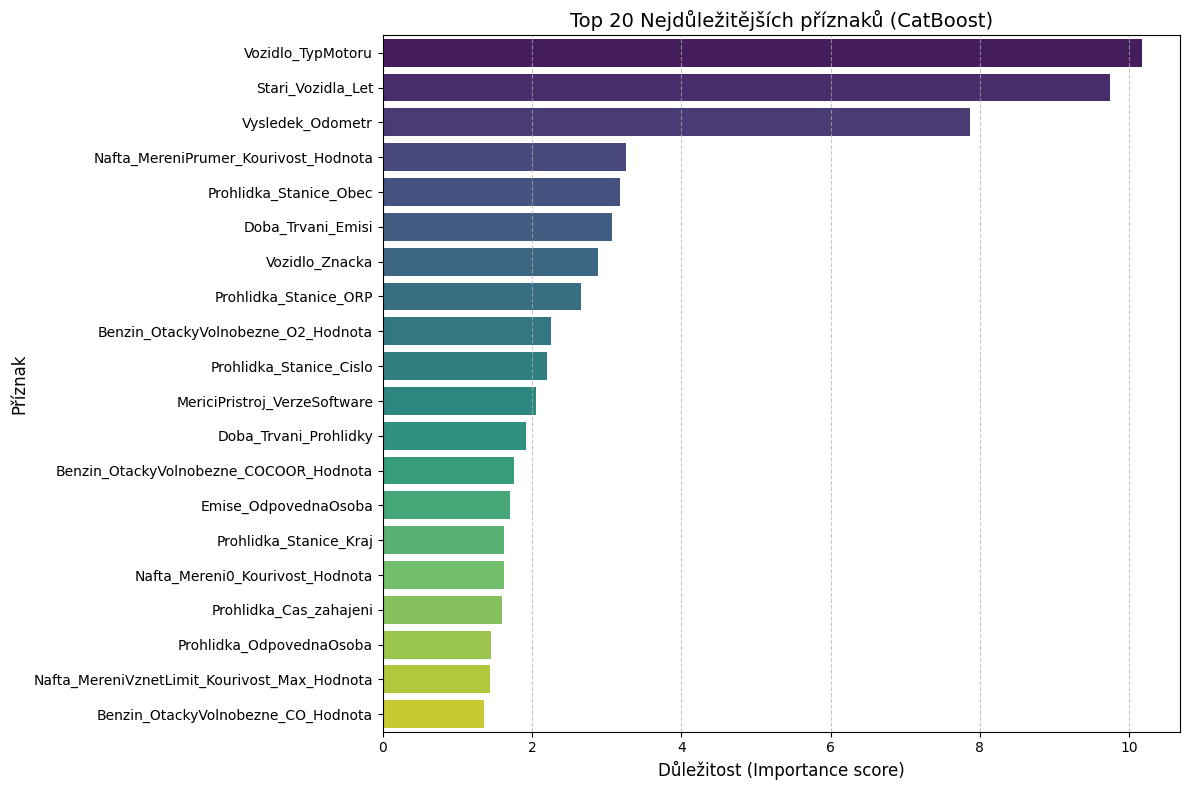

In [19]:
# Extraxe důležitosti příznaků
feature_importance = best_overall_model.get_feature_importance()
fi_df = pd.DataFrame({
    'feature': best_overall_features,
    'importance': feature_importance
})

# Seřazení a výběr top 20 (volitelně)
fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)

# Generování grafu
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance', 
    y='feature', 
    data=fi_df, 
    palette='viridis'
)

plt.title('Top 20 Nejdůležitějších příznaků (CatBoost)', fontsize=14)
plt.xlabel('Důležitost (Importance score)', fontsize=12)
plt.ylabel('Příznak', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10036/69847376.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_fi_test.head(20), palette='magma')


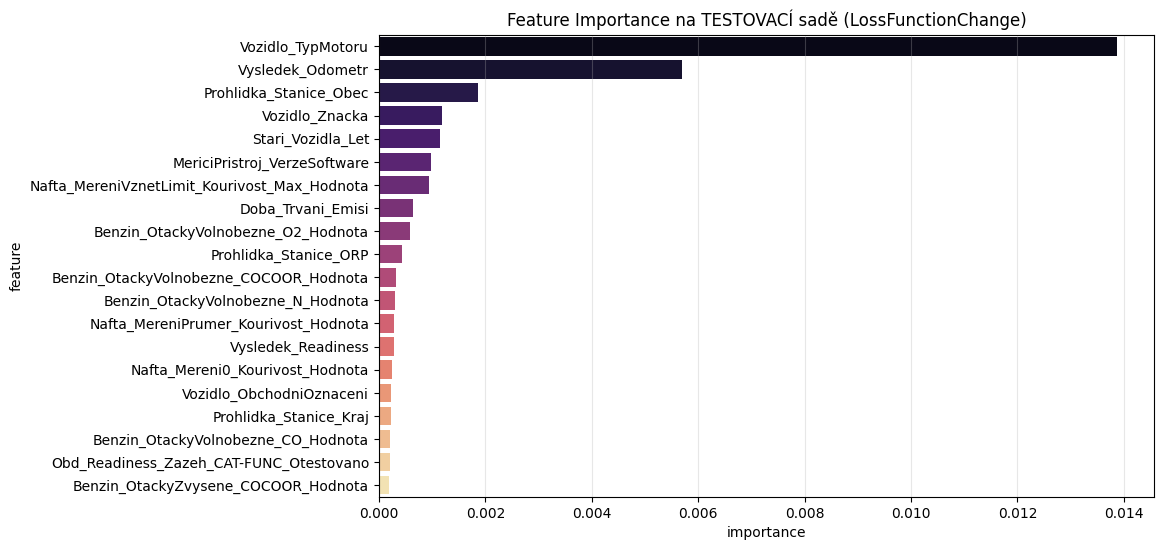

Test F1: 0.1501
              precision    recall  f1-score   support

           0       0.98      0.95      0.96    945089
           1       0.11      0.23      0.15     25692

    accuracy                           0.93    970781
   macro avg       0.54      0.59      0.56    970781
weighted avg       0.96      0.93      0.94    970781



In [20]:
# Příprava testovacích dat
current_cat_features_test = [c for c in cat_features if c in best_overall_features]
test_pool = Pool(X_test[best_overall_features], y_test, cat_features=current_cat_features_test)

# Predikce s optimálním prahem
y_test_proba = best_overall_model.predict_proba(test_pool)[:, 1]
y_test_pred = (y_test_proba >= best_overall_thr).astype(int)

# Výpočet důležitosti z testovací sady (LossFunctionChange)
fi_test = best_overall_model.get_feature_importance(
    data=test_pool, 
    type='LossFunctionChange',
    thread_count=-1
)

df_fi_test = pd.DataFrame({
    'feature': best_overall_features, 
    'importance': fi_test
}).sort_values(by='importance', ascending=False)

# Vizualizace
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=df_fi_test.head(20), palette='magma')
plt.title('Feature Importance na TESTOVACÍ sadě (LossFunctionChange)')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Finální report
print(f"Test F1: {f1_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred))